In [1]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [2]:
diabetes = load_diabetes()

# Create a DataFrame for easier manipulation
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

print("Dataset Shape:", df.shape)
print("\nFeature Names:", diabetes.feature_names)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (442, 11)

Feature Names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

First 5 rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
# Check for missing values
print("Missing Values per Column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print("\nNo missing values found! The dataset is clean.")

Missing Values per Column:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Total missing values: 0

No missing values found! The dataset is clean.


In [4]:
# Dataset basic statistics
print("Basic Statistics:")
df.describe()

Basic Statistics:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [5]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Split dataset: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size:  {X_test.shape[0]} samples")

# Normalize features using StandardScaler
# Fit only on training data to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nFeature normalization complete (StandardScaler applied).")
print(f"Training features mean (after scaling): {X_train_scaled.mean():.4f}")
print(f"Training features std  (after scaling): {X_train_scaled.std():.4f}")

Training set size: 353 samples
Testing set size:  89 samples

Feature normalization complete (StandardScaler applied).
Training features mean (after scaling): 0.0000
Training features std  (after scaling): 1.0000


---
## 2. Exploratory Data Analysis (EDA)

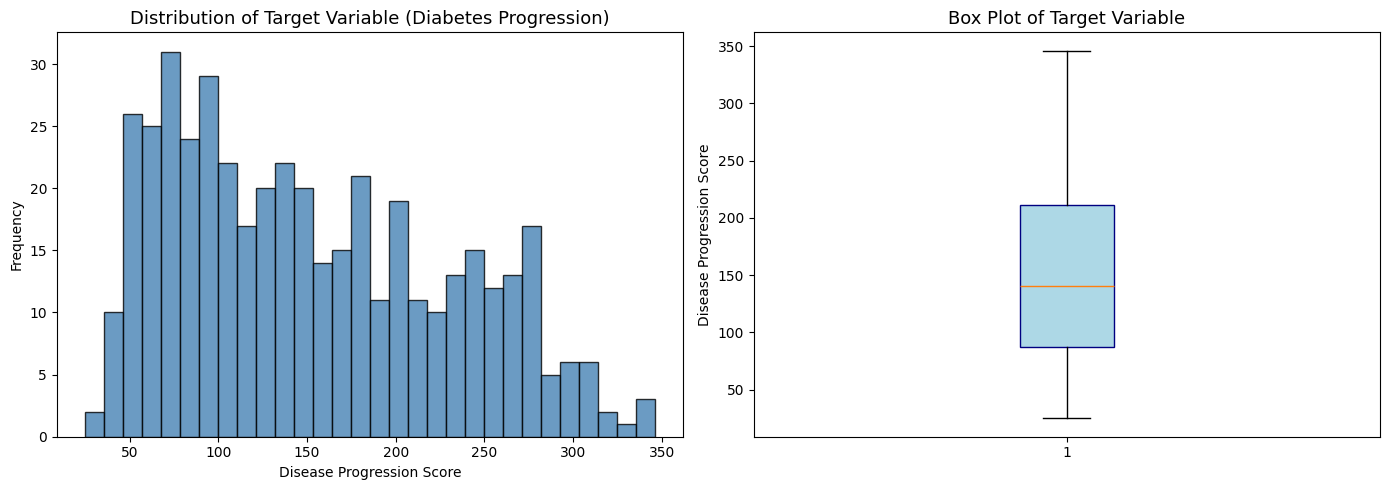

Target - Mean: 152.13, Std: 77.09
Target - Min: 25.00, Max: 346.00


In [6]:
# Distribution of Target Variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['target'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution of Target Variable (Diabetes Progression)', fontsize=13)
axes[0].set_xlabel('Disease Progression Score')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['target'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'))
axes[1].set_title('Box Plot of Target Variable', fontsize=13)
axes[1].set_ylabel('Disease Progression Score')

plt.tight_layout()
plt.show()

print(f"Target - Mean: {df['target'].mean():.2f}, Std: {df['target'].std():.2f}")
print(f"Target - Min: {df['target'].min():.2f}, Max: {df['target'].max():.2f}")

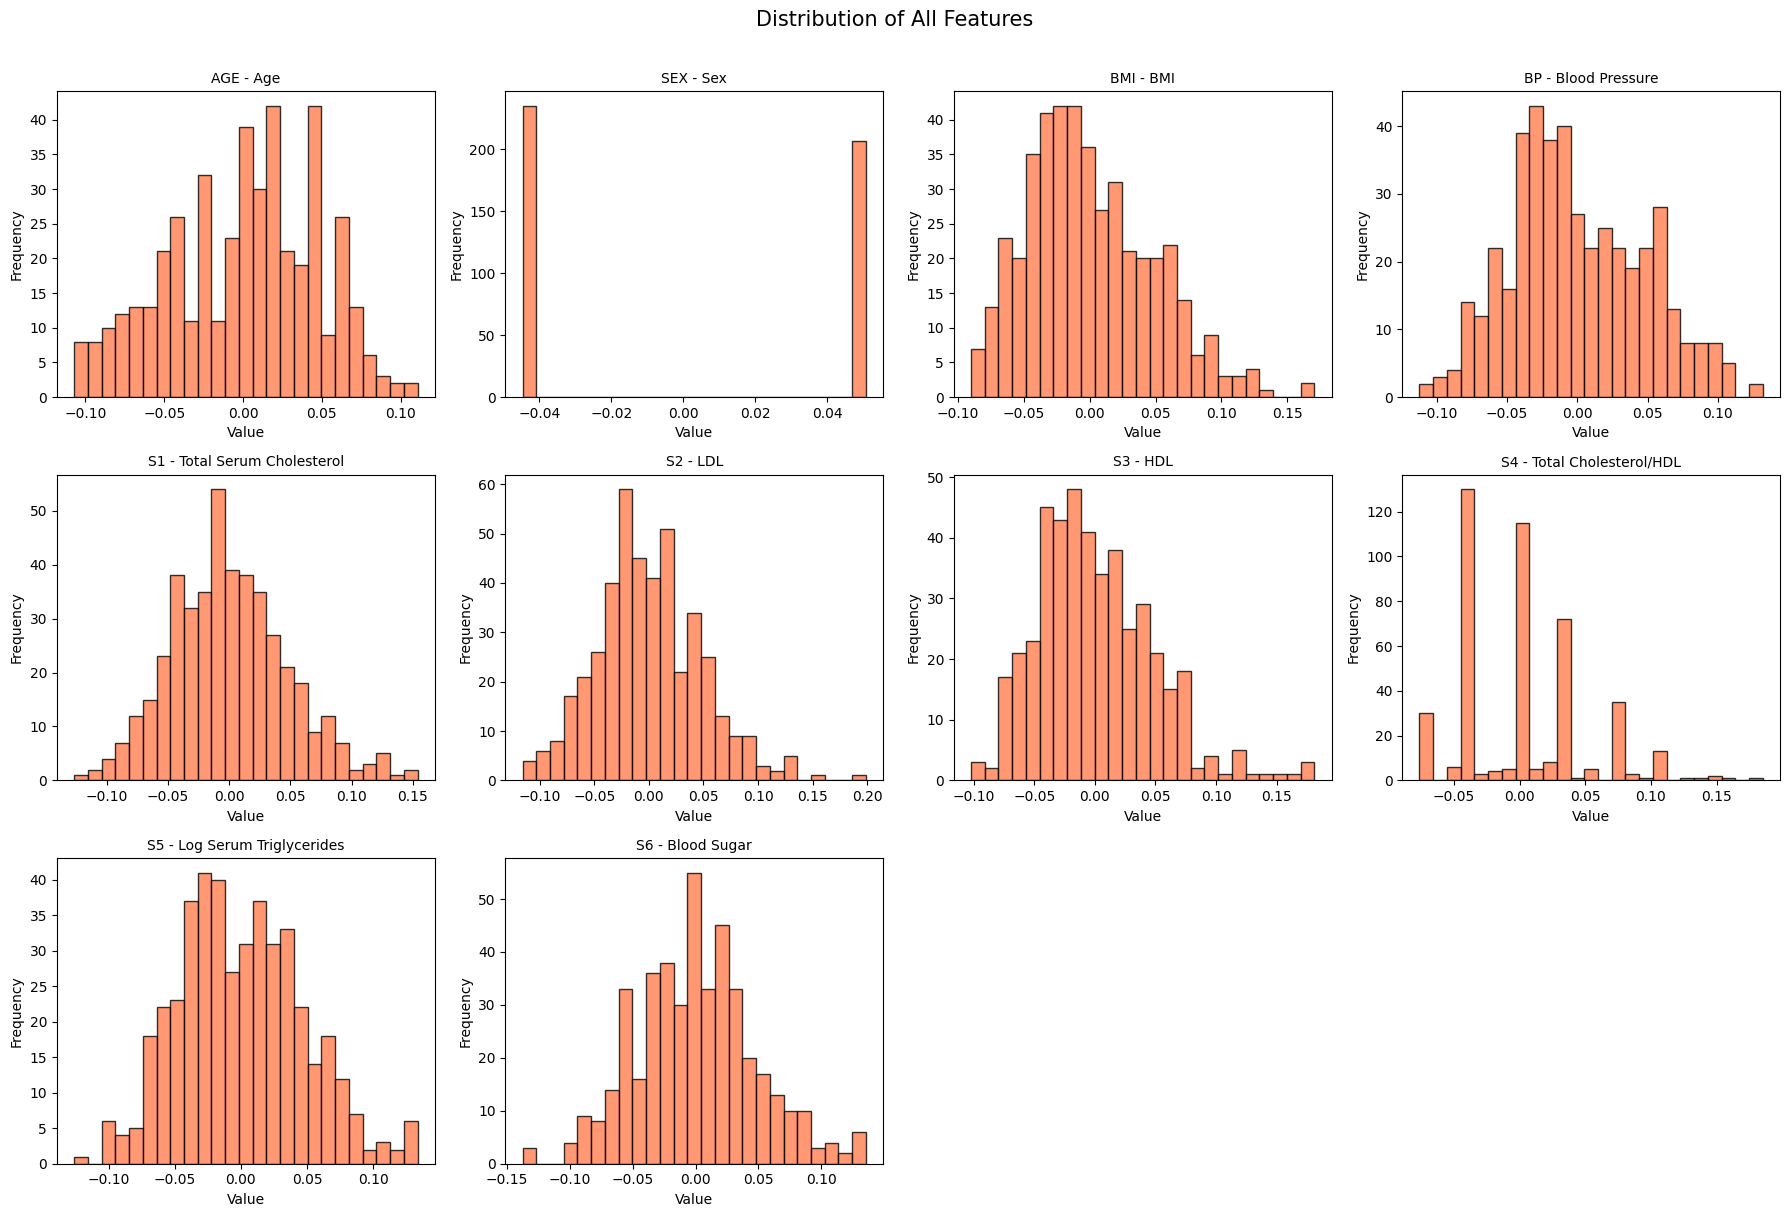

In [7]:
# Distribution of All Features
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

feature_descriptions = {
    'age': 'Age', 'sex': 'Sex', 'bmi': 'BMI',
    'bp': 'Blood Pressure', 's1': 'Total Serum Cholesterol',
    's2': 'LDL', 's3': 'HDL', 's4': 'Total Cholesterol/HDL',
    's5': 'Log Serum Triglycerides', 's6': 'Blood Sugar'
}

for i, col in enumerate(diabetes.feature_names):
    axes[i].hist(df[col], bins=25, color='coral', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'{col.upper()} - {feature_descriptions.get(col, col)}', fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hide unused subplots
for j in range(len(diabetes.feature_names), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of All Features', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

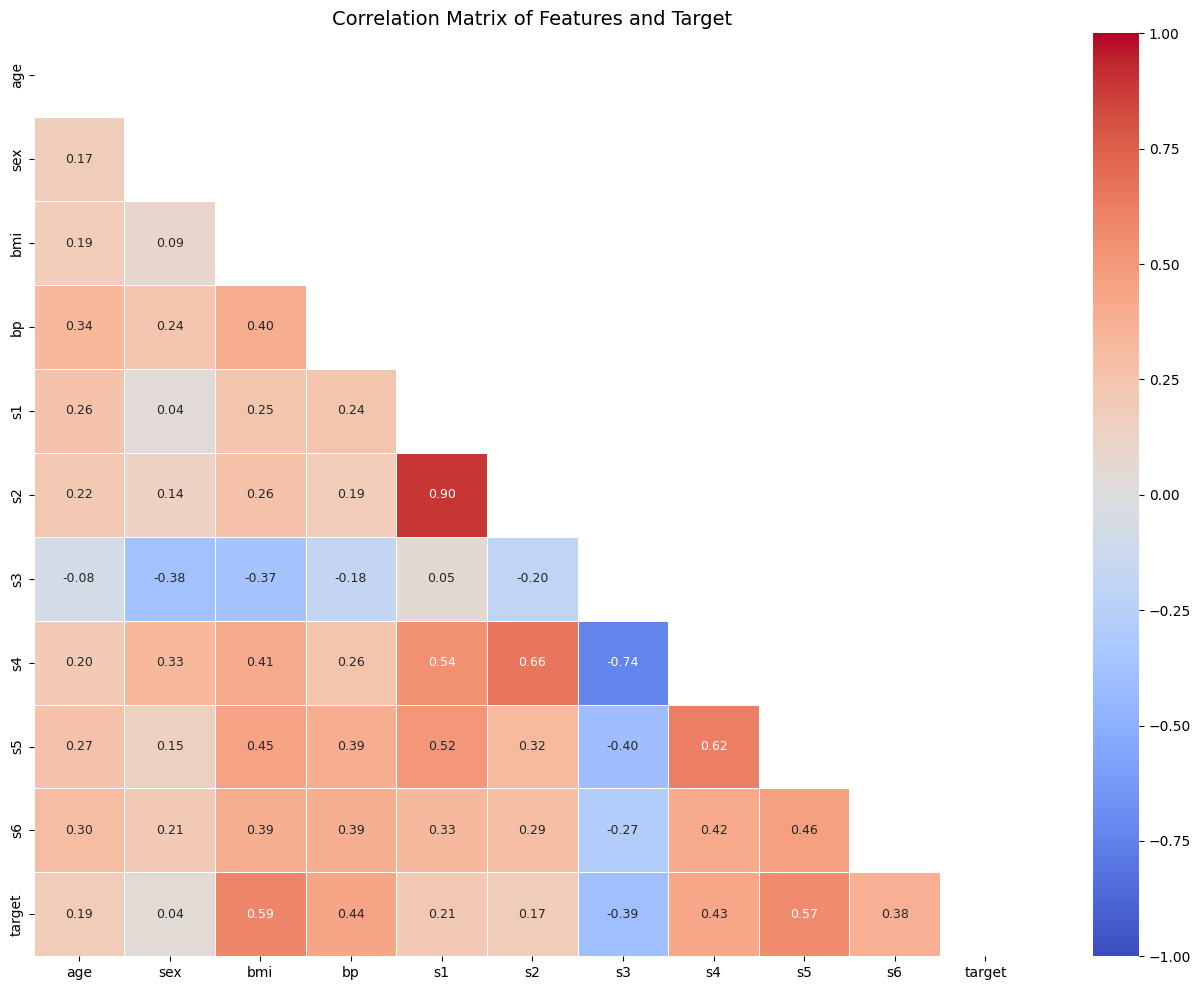


Top 5 features correlated with target:
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s3     0.394789
Name: target, dtype: float64


In [8]:
# Correlation Heatmap
plt.figure(figsize=(13, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 9})
plt.title('Correlation Matrix of Features and Target', fontsize=14)
plt.tight_layout()
plt.show()

print("\nTop 5 features correlated with target:")
print(corr_matrix['target'].drop('target').abs().sort_values(ascending=False).head())

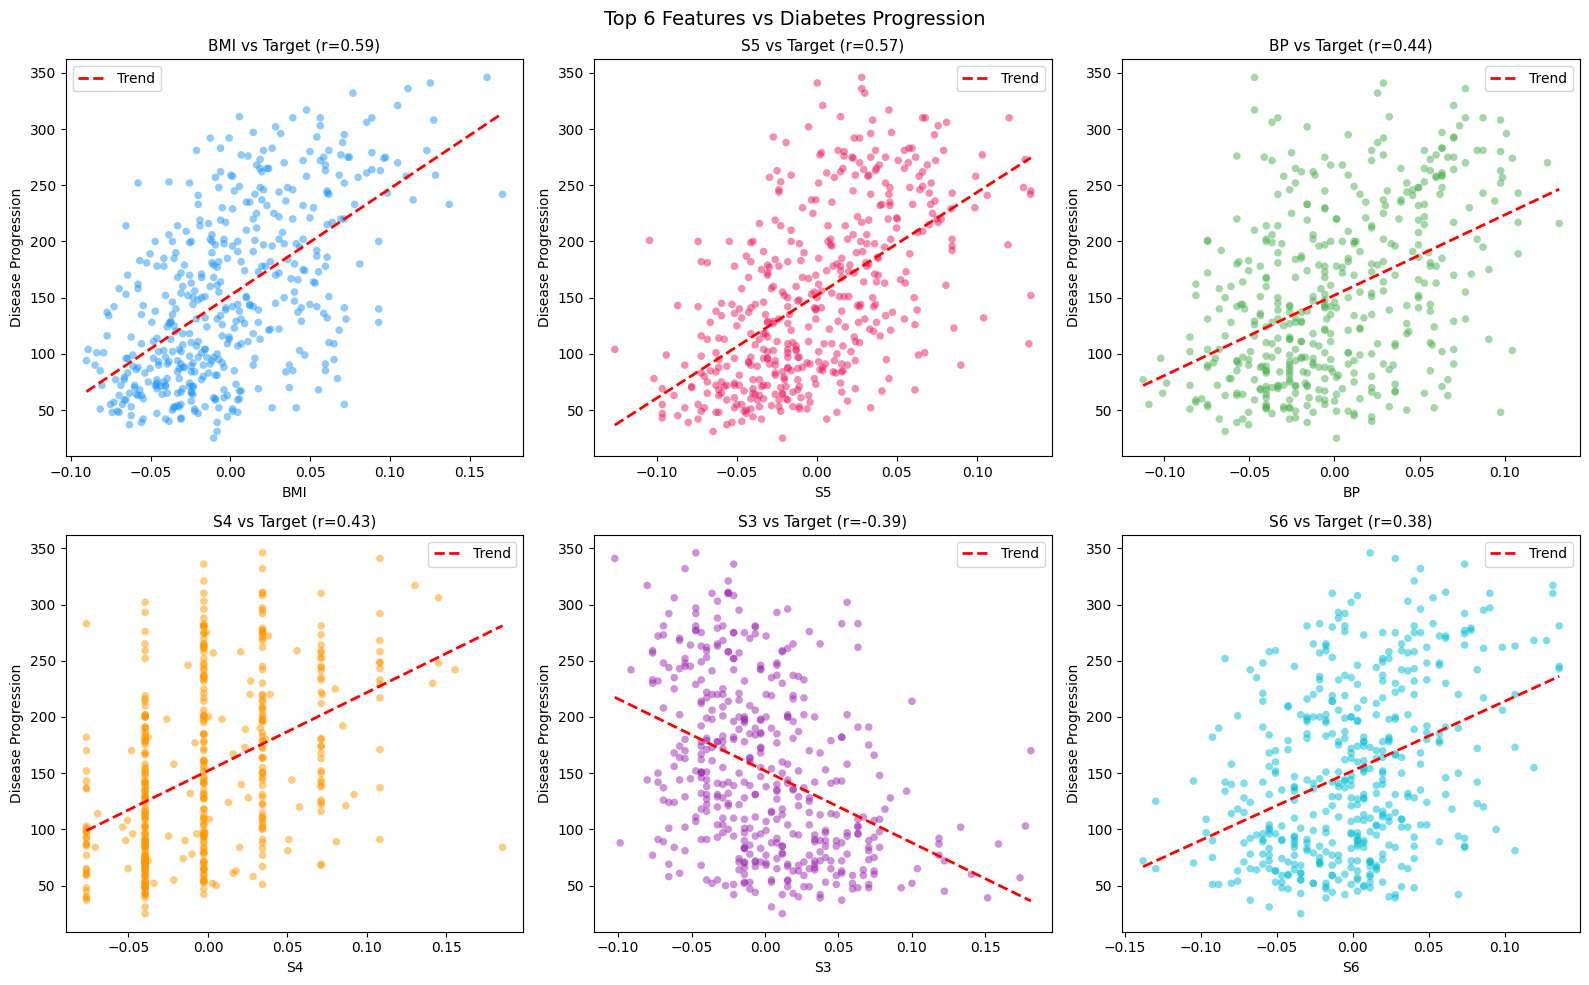

In [9]:
# Scatter plots: Top correlated features vs Target
top_features = corr_matrix['target'].drop('target').abs().sort_values(ascending=False).head(6).index

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colors = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']

for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df['target'], alpha=0.5, color=colors[i], edgecolors='none', s=30)
    z = np.polyfit(df[feat], df['target'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend')
    axes[i].set_title(f'{feat.upper()} vs Target (r={corr_matrix.loc[feat, "target"]:.2f})', fontsize=11)
    axes[i].set_xlabel(feat.upper())
    axes[i].set_ylabel('Disease Progression')
    axes[i].legend()

plt.suptitle('Top 6 Features vs Diabetes Progression', fontsize=14)
plt.tight_layout()
plt.show()

---
## 3. Building the Baseline ANN Model

In [10]:
def build_baseline_model(input_dim):
    """
    Baseline ANN Architecture:
    - Input Layer: 10 features
    - Hidden Layer 1: 32 neurons, ReLU activation
    - Hidden Layer 2: 16 neurons, ReLU activation
    - Output Layer: 1 neuron, Linear activation (regression)
    """
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation='relu', name='hidden_1'),
        layers.Dense(16, activation='relu', name='hidden_2'),
        layers.Dense(1, activation='linear', name='output')
    ], name='Baseline_ANN')
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mean_squared_error',
        metrics=['mae']
    )
    return model

baseline_model = build_baseline_model(X_train_scaled.shape[1])
baseline_model.summary()

Model: "Baseline_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                     │ (None, 32)                  │             352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_2 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

---
## 4. Training the Baseline ANN Model

In [11]:
# Early stopping to prevent overfitting
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True
)

# Train the baseline model
history_baseline = baseline_model.fit(
    X_train_scaled, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)

print(f"Training stopped at epoch: {len(history_baseline.history['loss'])}")
print(f"Best validation loss: {min(history_baseline.history['val_loss']):.2f}")

Training stopped at epoch: 300
Best validation loss: 3245.78


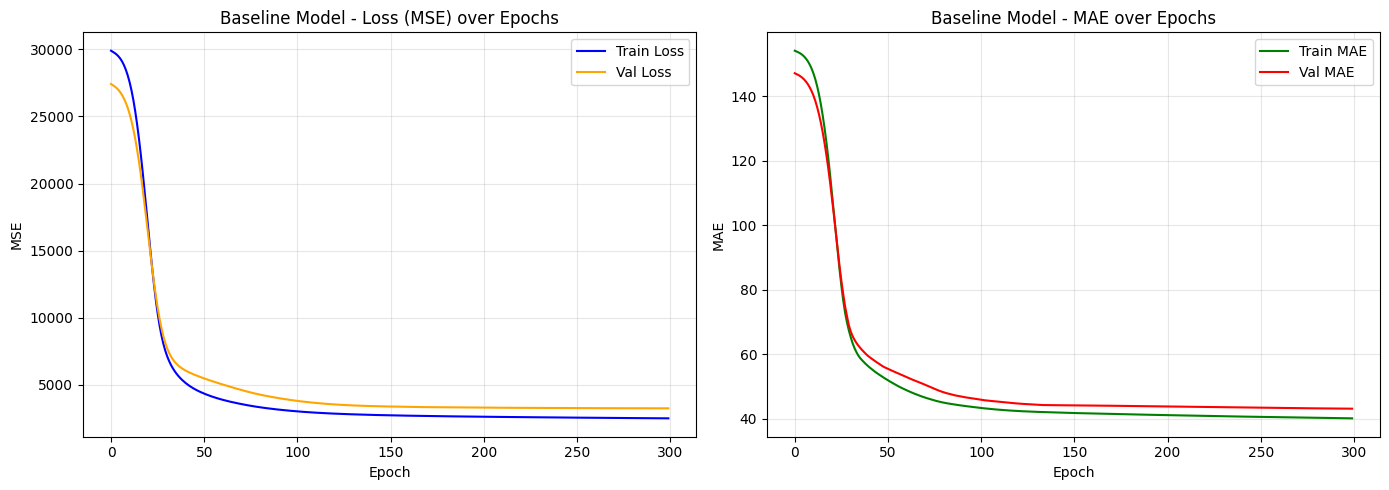

In [12]:
# Plot training history
def plot_training_history(history, title='Baseline Model'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(history.history['loss'], label='Train Loss', color='blue')
    axes[0].plot(history.history['val_loss'], label='Val Loss', color='orange')
    axes[0].set_title(f'{title} - Loss (MSE) over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(history.history['mae'], label='Train MAE', color='green')
    axes[1].plot(history.history['val_mae'], label='Val MAE', color='red')
    axes[1].set_title(f'{title} - MAE over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history_baseline, 'Baseline Model')

---
## 5. Evaluating the Baseline Model

In [13]:
def evaluate_model(model, X_test_scaled, y_test, model_name='Model'):
    y_pred = model.predict(X_test_scaled, verbose=0).flatten()
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mae = np.mean(np.abs(y_test - y_pred))
    
    print(f"\n{'='*45}")
    print(f" {model_name} - Performance Metrics")
    print(f"{'='*45}")
    print(f"  Mean Squared Error  (MSE) : {mse:.4f}")
    print(f"  Root MSE           (RMSE) : {rmse:.4f}")
    print(f"  Mean Absolute Error (MAE) : {mae:.4f}")
    print(f"  R² Score                  : {r2:.4f}")
    print(f"{'='*45}")
    
    return y_pred, {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}

y_pred_baseline, metrics_baseline = evaluate_model(
    baseline_model, X_test_scaled, y_test, 'Baseline ANN'
)


 Baseline ANN - Performance Metrics
  Mean Squared Error  (MSE) : 2783.7512
  Root MSE           (RMSE) : 52.7613
  Mean Absolute Error (MAE) : 41.9882
  R² Score                  : 0.4746


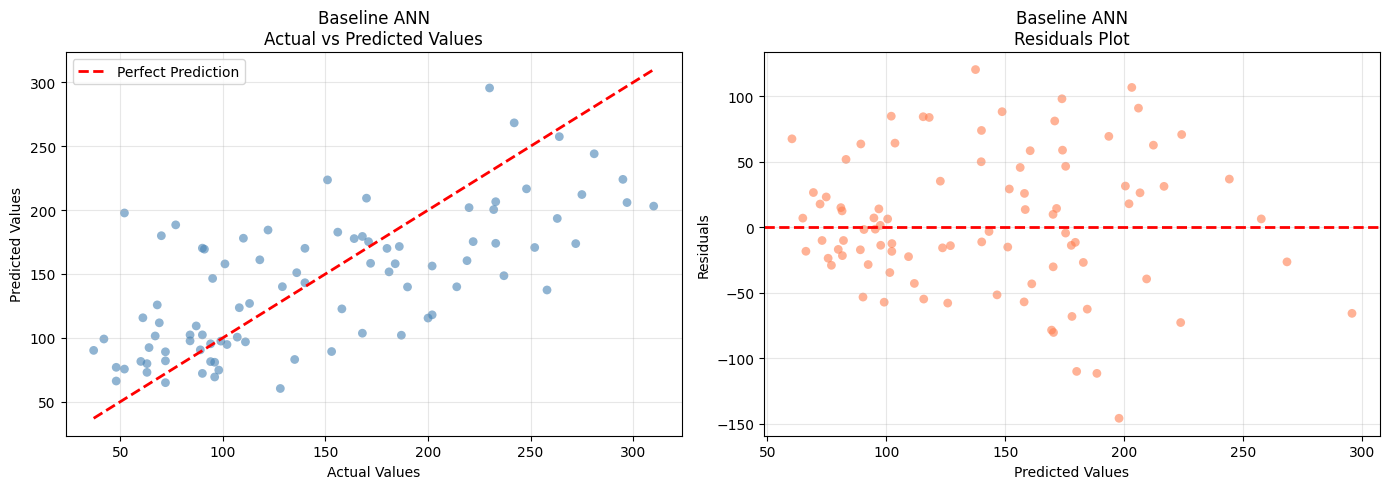

In [14]:
# Visualize predictions vs actual
def plot_predictions(y_test, y_pred, title='Baseline Model'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Actual vs Predicted scatter
    axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='none', s=40)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    axes[0].set_title(f'{title}\nActual vs Predicted Values')
    axes[0].set_xlabel('Actual Values')
    axes[0].set_ylabel('Predicted Values')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Residuals
    residuals = y_test.values - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.6, color='coral', edgecolors='none', s=40)
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1].set_title(f'{title}\nResiduals Plot')
    axes[1].set_xlabel('Predicted Values')
    axes[1].set_ylabel('Residuals')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_predictions(y_test, y_pred_baseline, 'Baseline ANN')

In [15]:
def build_improved_model(input_dim):
    """
    Improved ANN Architecture:
    - Deeper network: 3 hidden layers (64 → 32 → 16)
    - Batch Normalization after each hidden layer
    - Dropout (0.2) for regularization
    - He Normal initialization for ReLU layers
    """
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        
        layers.Dense(64, kernel_initializer='he_normal', name='hidden_1'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),
        
        layers.Dense(32, kernel_initializer='he_normal', name='hidden_2'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),
        
        layers.Dense(16, kernel_initializer='he_normal', name='hidden_3'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        
        layers.Dense(1, activation='linear', name='output')
    ], name='Improved_ANN')
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mean_squared_error',
        metrics=['mae']
    )
    return model

improved_model = build_improved_model(X_train_scaled.shape[1])
improved_model.summary()

Model: "Improved_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                     │ (None, 64)                  │             704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_2 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_3 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,553 (13.88 KB)

 Non-trainable params: 224 (896.00 B)

In [16]:
# Callbacks for improved model
early_stop_imp = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True
)
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5, verbose=1
)

history_improved = improved_model.fit(
    X_train_scaled, y_train,
    epochs=500,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop_imp, lr_scheduler],
    verbose=0
)

print(f"Training stopped at epoch: {len(history_improved.history['loss'])}")
print(f"Best validation loss: {min(history_improved.history['val_loss']):.2f}")


Epoch 136: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 209: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 229: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 239: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 249: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Training stopped at epoch: 249
Best validation loss: 4346.92


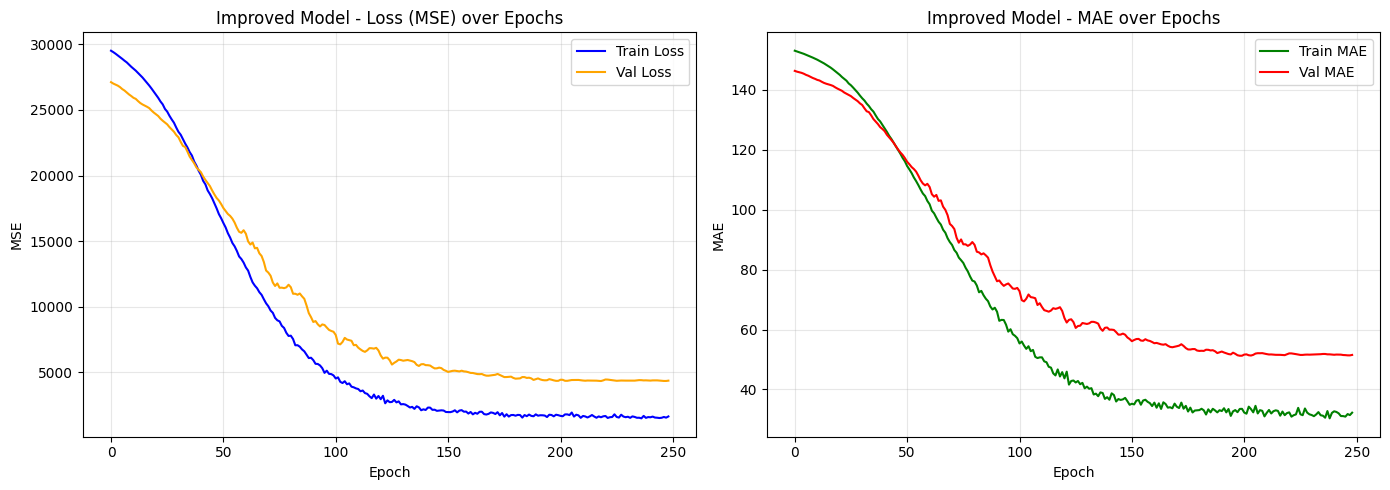

In [17]:
plot_training_history(history_improved, 'Improved Model')

In [18]:
y_pred_improved, metrics_improved = evaluate_model(
    improved_model, X_test_scaled, y_test, 'Improved ANN'
)


 Improved ANN - Performance Metrics
  Mean Squared Error  (MSE) : 3385.0581
  Root MSE           (RMSE) : 58.1813
  Mean Absolute Error (MAE) : 46.1459
  R² Score                  : 0.3611


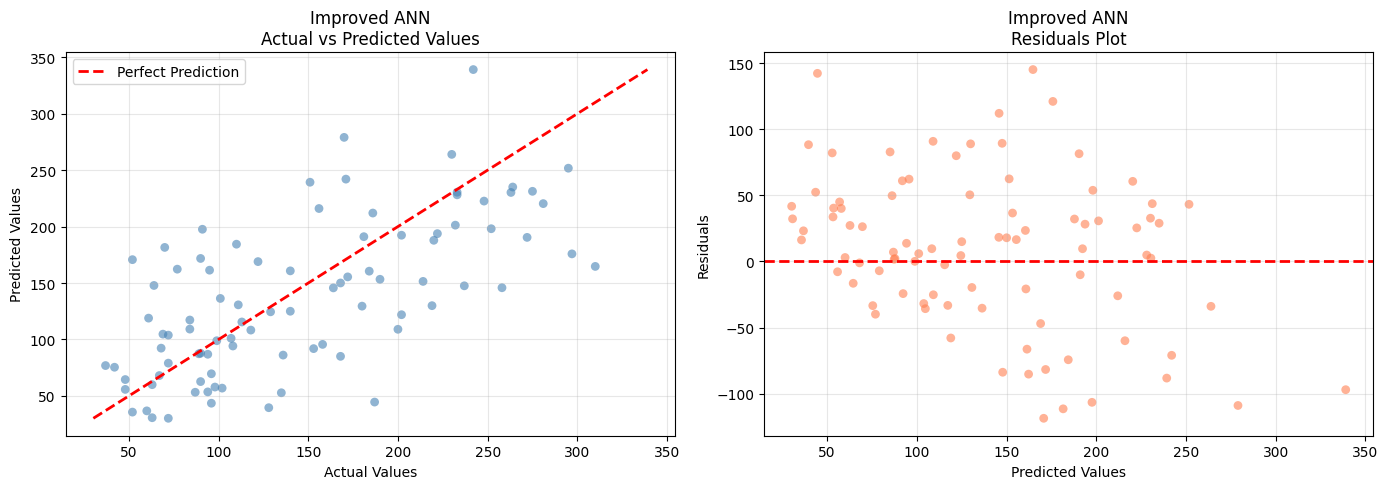

In [19]:
plot_predictions(y_test, y_pred_improved, 'Improved ANN')

In [20]:
# Side-by-side metrics comparison
comparison = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R² Score'],
    'Baseline ANN': [
        round(metrics_baseline['mse'], 4),
        round(metrics_baseline['rmse'], 4),
        round(metrics_baseline['mae'], 4),
        round(metrics_baseline['r2'], 4)
    ],
    'Improved ANN': [
        round(metrics_improved['mse'], 4),
        round(metrics_improved['rmse'], 4),
        round(metrics_improved['mae'], 4),
        round(metrics_improved['r2'], 4)
    ]
})
comparison['Change'] = comparison.apply(
    lambda row: f"{((row['Improved ANN'] - row['Baseline ANN']) / abs(row['Baseline ANN']) * 100):+.2f}%"
    if row['Metric'] != 'R² Score'
    else f"{((row['Improved ANN'] - row['Baseline ANN']) / abs(row['Baseline ANN']) * 100):+.2f}%",
    axis=1
)

print(comparison.to_string(index=False))

  Metric  Baseline ANN  Improved ANN  Change
     MSE     2783.7512     3385.0581 +21.60%
    RMSE       52.7613       58.1813 +10.27%
     MAE       41.9882       46.1459  +9.90%
R² Score        0.4746        0.3611 -23.91%


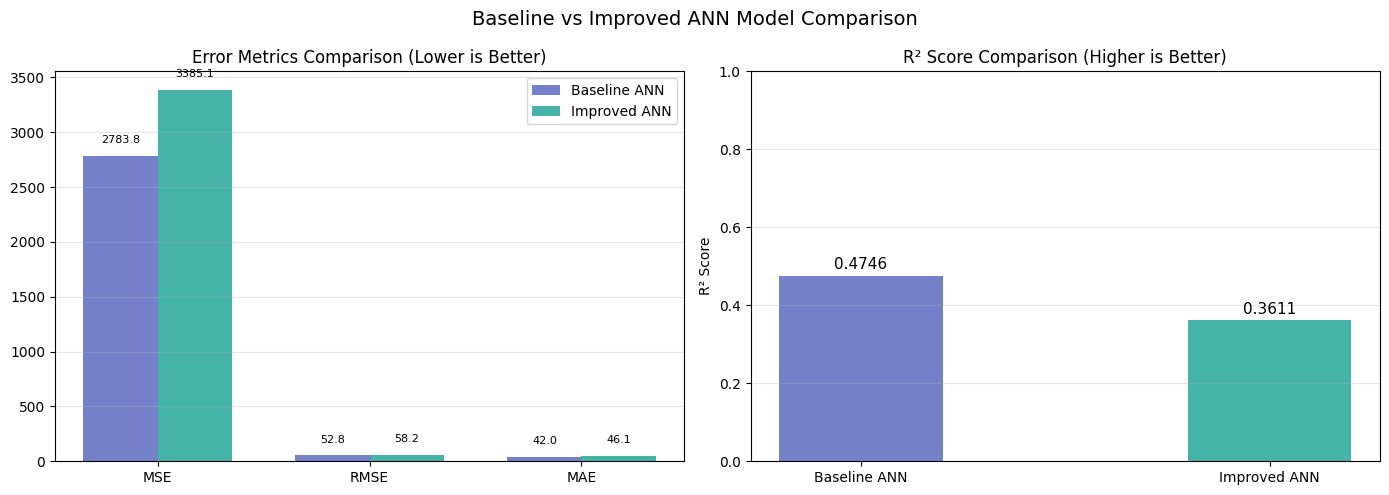

In [21]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_list = ['mse', 'rmse', 'mae']
labels = ['MSE', 'RMSE', 'MAE']
baseline_vals = [metrics_baseline[m] for m in metrics_list]
improved_vals = [metrics_improved[m] for m in metrics_list]

x = np.arange(len(labels))
width = 0.35
bars1 = axes[0].bar(x - width/2, baseline_vals, width, label='Baseline ANN', color='#5C6BC0', alpha=0.85)
bars2 = axes[0].bar(x + width/2, improved_vals, width, label='Improved ANN', color='#26A69A', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_title('Error Metrics Comparison (Lower is Better)')
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)
for bar in bars1: axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
                               f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars2: axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
                               f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

r2_vals = [metrics_baseline['r2'], metrics_improved['r2']]
colors = ['#5C6BC0', '#26A69A']
bars = axes[1].bar(['Baseline ANN', 'Improved ANN'], r2_vals, color=colors, alpha=0.85, width=0.4)
axes[1].set_title('R² Score Comparison (Higher is Better)')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1)
axes[1].grid(True, axis='y', alpha=0.3)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=11)

plt.suptitle('Baseline vs Improved ANN Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()

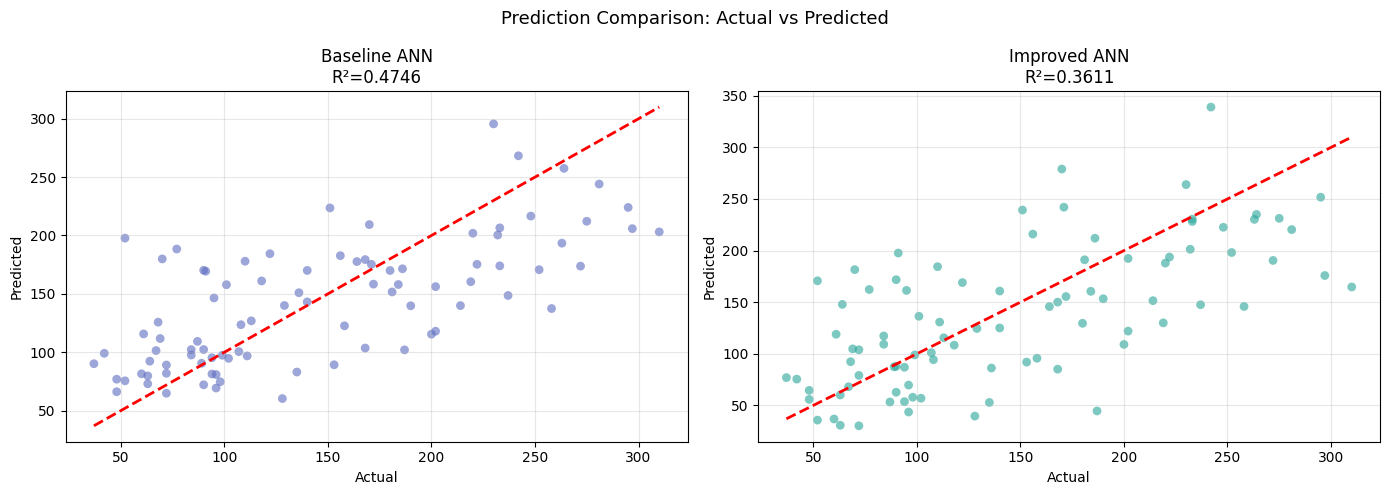

In [22]:
# Overlay prediction comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title, color in zip(
    axes,
    [y_pred_baseline, y_pred_improved],
    ['Baseline ANN', 'Improved ANN'],
    ['#5C6BC0', '#26A69A']
):
    ax.scatter(y_test, y_pred, alpha=0.6, color=color, edgecolors='none', s=40)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_title(f'{title}\nR²={r2_score(y_test, y_pred):.4f}')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.grid(True, alpha=0.3)

plt.suptitle('Prediction Comparison: Actual vs Predicted', fontsize=13)
plt.tight_layout()
plt.show()